# Video S1. Morph movie summarizing remodeling between uninfected and infected UMAPs

In [1]:
import numpy as np
import pandas as pd
import os
from matplotlib import pyplot as plt
import pandas as pd

output_folder = "output"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

In [2]:
# install the scimap package required for making the morph movie
%pip install scimap
%pip install "anndata==0.10.8" "scanpy==1.10.2"

import scimap as sm
import anndata as ad

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Running SCIMAP  2.3.5


/Users/duo.peng/miniforge3/envs/OrgIP/lib/python3.10/site-packages/mpl_scatter_density/__init__.py:4: UserWarning:

pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



### Load data

In [3]:
%store -r fig5_timestamp
print(f"Timestamp: {fig5_timestamp}")

Timestamp: 2023-10-21-for-figures


In [4]:
# Load aligned UMAP data
input_folder = '../../Fig5/panel_A/3.aligned_umap/output'
umap_morph_data = pd.read_csv(os.path.join(input_folder,f"{fig5_timestamp}_AlignedUMAP_embeddings_and_distances.csv"))
umap_morph_data.set_index("Protein IDs", inplace=True)
print(umap_morph_data.shape)



(8014, 66)


In [5]:
input_folder = '../../Fig5/panel_E/output'
sankey_umap_table = pd.read_csv(os.path.join(input_folder, "Sankey_umap_table.csv"))
sankey_umap_table.set_index("Protein IDs", inplace=True)
print(sankey_umap_table.shape)

(8014, 78)


In [6]:
# check if the two dataframes have the same index
print(umap_morph_data.index.equals(sankey_umap_table.index))


True


## The morph movie

In [7]:
# prepare an adata object for the movie
col_uninf_inf = [i for i in umap_morph_data.columns if (i.startswith("0") or i.startswith("1")) and ("bootstraps") not in i]
adata_df = pd.DataFrame(umap_morph_data, columns = col_uninf_inf)
#adata_df = adata_df.rename(columns={"Gene names_uninfo":"Gene names"})

adata = ad.AnnData(adata_df)  

adata.obs_names = [str(i) for i in umap_morph_data.index.to_list()]
adata.var_names = col_uninf_inf

adata.obsm["coordinates_umap_uninf"] = np.column_stack([umap_morph_data["JointUMAP_uninf_1"].to_list(), umap_morph_data["JointUMAP_uninf_2"].to_list()])
adata.obsm["coordinates_umap_inf"] = np.column_stack([umap_morph_data["JointUMAP_inf_1"].to_list(), umap_morph_data["JointUMAP_inf_2"].to_list()])
adata.obs["Sankey_left"] = sankey_umap_table["cluster_annot_uninf"].to_list()
adata.obs["Gene_name_canonical"] = sankey_umap_table["Gene_name_canonical"].to_list()
adata.obs["Protein IDs"] = umap_morph_data.index.to_list()

# flip the y coordinates (or else the movie will be "upside down")
adata.obsm["coordinates_umap_uninf"][:, 1] = -adata.obsm["coordinates_umap_uninf"][:, 1]
adata.obsm["coordinates_umap_inf"][:, 1] = -adata.obsm["coordinates_umap_inf"][:, 1]
# flip the x coordinates
adata.obsm["coordinates_umap_uninf"][:, 0] = -adata.obsm["coordinates_umap_uninf"][:, 0]
adata.obsm["coordinates_umap_inf"][:, 0] = -adata.obsm["coordinates_umap_inf"][:, 0]

adata

AnnData object with n_obs × n_vars = 8014 × 50
    obs: 'Sankey_left', 'Gene_name_canonical', 'Protein IDs'
    obsm: 'coordinates_umap_uninf', 'coordinates_umap_inf'

In [8]:
# format the data for scimap (it is a bit hard-coded)
adata.obsm["umap"] = adata.obsm["coordinates_umap_uninf"]

# format the spatial data (adata.obs["X_centroid"], or Y_centroid, Area)
adata.obsm["X_spatial"] = adata.obsm["coordinates_umap_inf"]
X_coordinates = [x[0] for x in adata.obsm["X_spatial"]]
Y_coordinates = [x[1] for x in adata.obsm["X_spatial"]]

# map the coordinates back to the adata
adata.obs["X_centroid"] = X_coordinates
adata.obs["Y_centroid"] = Y_coordinates
adata.obs["Area"] = 10

In [9]:
colorDict = {
    "nucleus": "#DB5F57",
    "cytosol": "#A2CE5A",
    "mitochondrion": "#59B6DC",
    "ER": "#DB9C58",
    "plasma memb. & actin": "#B96EAD",
    "endo-lysosome & trans-Golgi": "#DBD956",
    "ERGIC/Golgi": "#6BC7BB",
    "translation/RNA granules": "#414042",
    "signaling scaffold": "yellow",
    "peroxisome": "#EC008C",
    "COPI vesicle": "red",
    "centrosome": "#955FA7",
    "unclassified": "grey",
}

/Users/duo.peng/miniforge3/envs/OrgIP/lib/python3.10/site-packages/scimap/helpers/animate.py:241: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/Users/duo.peng/miniforge3/envs/OrgIP/lib/python3.10/site-packages/scimap/helpers/animate.py:420: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored

MovieWriter imagemagick unavailable; using Pillow instead.


Saving file- This can take several minutes to hours for large files


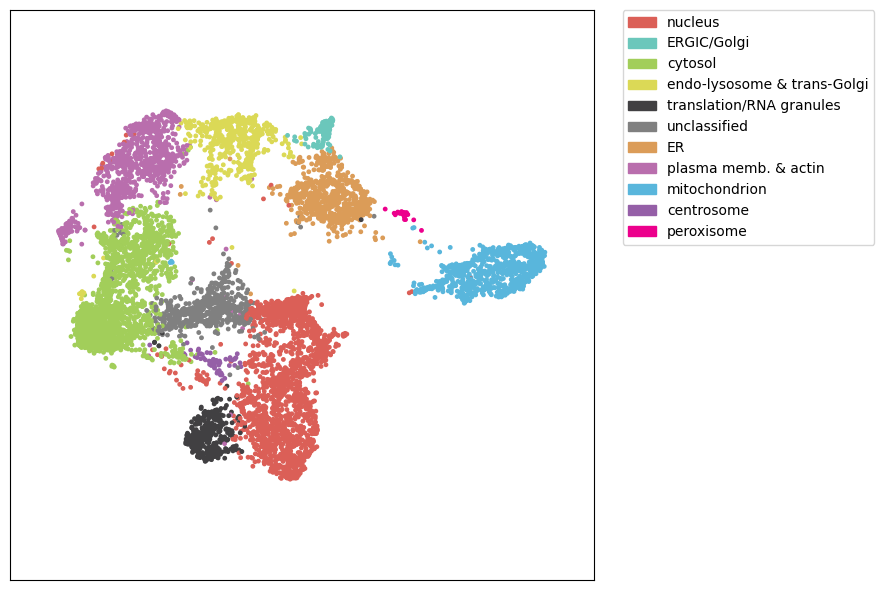

In [10]:
# Run the scimap script to generate gif files
col_name = "Sankey_left"
s = 6
anim = sm.hl.animate(adata, color=col_name, s = s, flip_y = False, n_frames=100, final_frame=20, watermark=False,
                     plot_legend=True,figsize =(9,6),
                    save_animation = os.path.join("output",f"movie_{col_name}_pointsize={s}.gif"), palette = colorDict)
plt.show()